# Week 6 - Decision Trees and Random Forests

In [1]:
#pip install pandas numpy scikit-learn matplotlib seaborn kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import kagglehub

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("All imports successful.")

All imports successful.


## 1. Data Loading & Cleaning

In [3]:
#Load from Kaggle
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

#Cleaning
df = df.drop_duplicates()

# Median imputation for employment length (right-skewed, so median > mean here)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Grade-matched median for interest rate - preserves credit-grade logic
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median')
)

# Remove logical impossibilities (not just statistical outliers)
df = df[df['person_emp_length'] <= df['person_age']]
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate (loan_status=1): {df['loan_status'].mean()*100:.2f}%")
print(f"\nColumn types:\n{df.dtypes}")

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate (loan_status=1): 21.87%

Column types:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


---
## 2. Setup: Classification Target and Encoded Features

In [4]:
numeric_features = ['person_income', 'person_age', 'person_emp_length',
                    'loan_amnt', 'loan_percent_income', 'loan_int_rate']
categorical_features = ['loan_intent', 'loan_grade',
                        'person_home_ownership', 'cb_person_default_on_file']

X = df[numeric_features + categorical_features].copy()
y = df['loan_status'].copy()
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Trees are scale-invariant (splits are thresholds, not distances), so unlike Weeks 4-5 we do
# NOT need to scale. We still one-hot encode categoricals so every column is a usable split.
encoder = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)
feat_names = numeric_features + encoder.named_transformers_['cat'] \
    .get_feature_names_out(categorical_features).tolist()

print(f"Encoded features: {len(feat_names)} | Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Default rate: {y.mean()*100:.1f}%")
print()
print("Interpretation: Note what we DON'T do - no scaling. A tree asks 'is income > 50000?',")
print("a question whose answer is unchanged by rescaling. That scale-invariance is one of the")
print("quiet practical advantages of trees over the SVM and logistic models of Weeks 4-5.")

Encoded features: 25 | Train: 25,927 | Test: 6,482
Default rate: 21.9%

Interpretation: Note what we DON'T do - no scaling. A tree asks 'is income > 50000?',
a question whose answer is unchanged by rescaling. That scale-invariance is one of the
quiet practical advantages of trees over the SVM and logistic models of Weeks 4-5.


## 3. A Single Decision Tree: Rules You Can Read

Decision Tree (depth 4) Test AUC: 0.8695

              precision    recall  f1-score   support

      Repaid       0.93      0.94      0.93      5064
     Default       0.76      0.73      0.75      1418

    accuracy                           0.89      6482
   macro avg       0.84      0.83      0.84      6482
weighted avg       0.89      0.89      0.89      6482



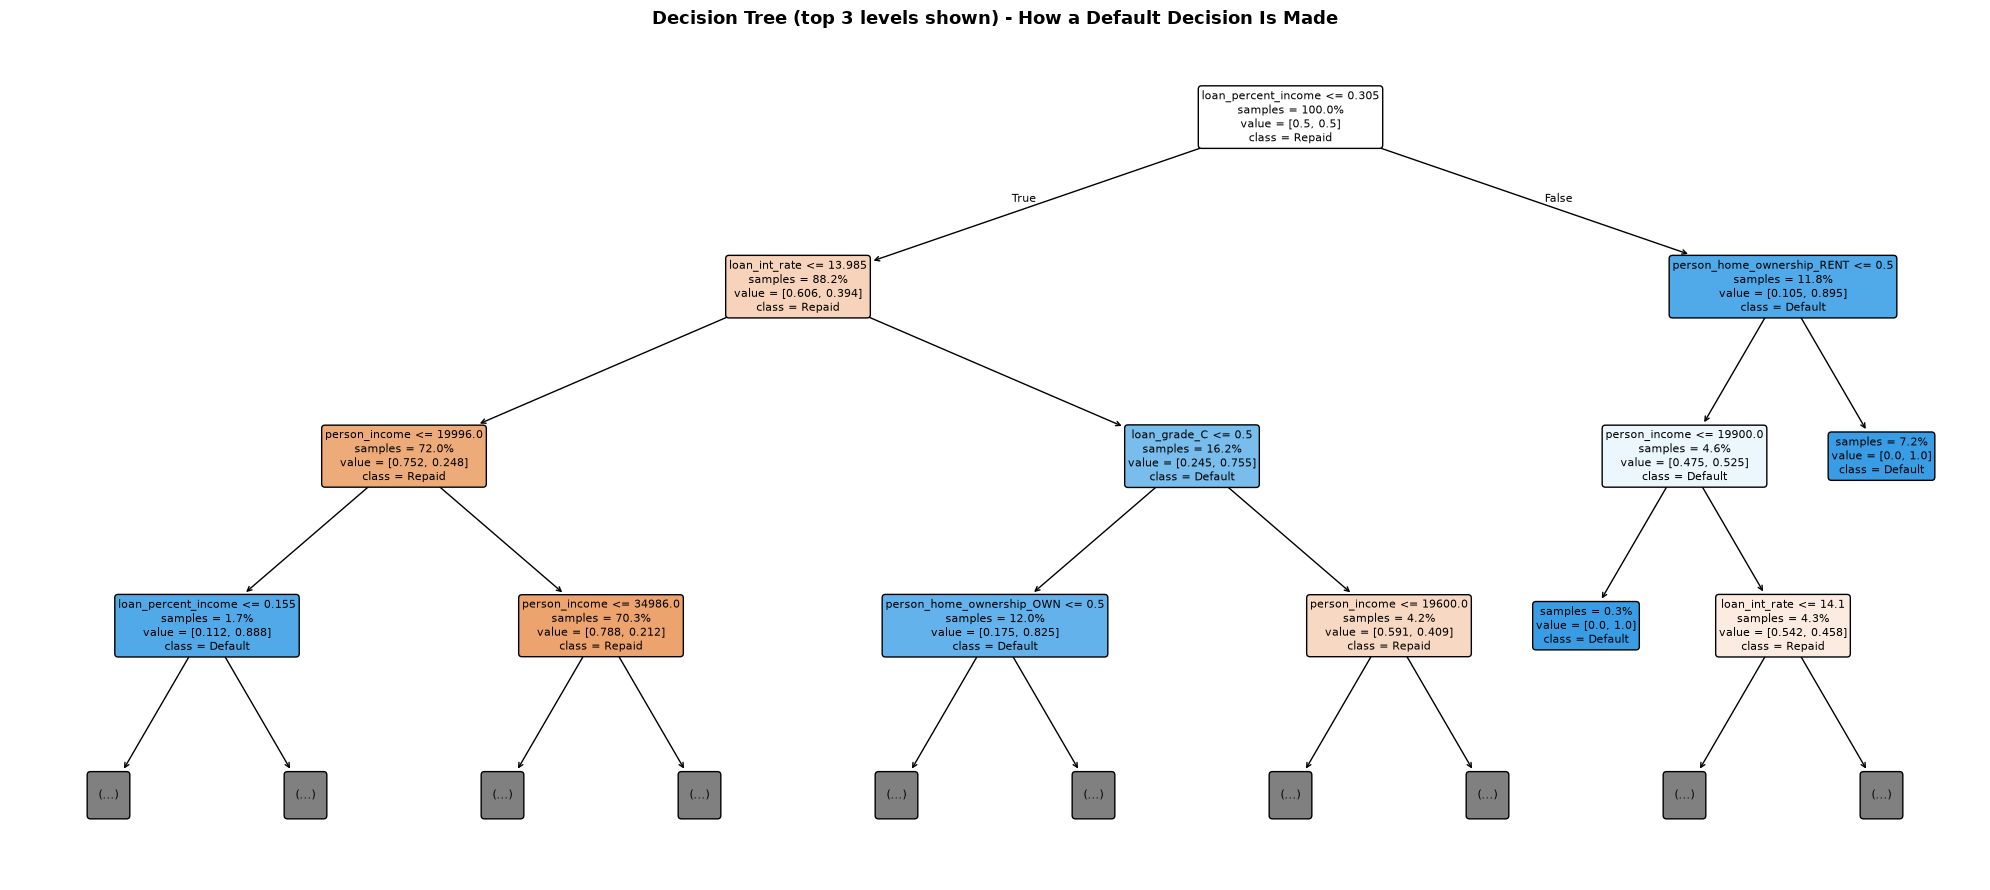

Interpretation: Every path from root to leaf is a plain-language underwriting rule
(e.g. 'high debt burden AND high rate -> likely default'). This readability is the
tree's headline strength - a declined applicant could be shown the exact rule path.


In [5]:
# A shallow tree first, so the rules are legible. class_weight handles the imbalance.
tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X_train_enc, y_train)
proba_tree = tree.predict_proba(X_test_enc)[:, 1]
auc_tree = roc_auc_score(y_test, proba_tree)
print(f"Decision Tree (depth 4) Test AUC: {auc_tree:.4f}")
print()
print(classification_report(y_test, tree.predict(X_test_enc),
                            target_names=['Repaid', 'Default']))

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(tree, feature_names=feat_names, class_names=['Repaid', 'Default'],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax,
          impurity=False, proportion=True)
ax.set_title('Decision Tree (top 3 levels shown) - How a Default Decision Is Made',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretation: Every path from root to leaf is a plain-language underwriting rule")
print("(e.g. 'high debt burden AND high rate -> likely default'). This readability is the")
print("tree's headline strength - a declined applicant could be shown the exact rule path.")

---
## 4. Depth as a Regularizer: Watching a Tree Overfit

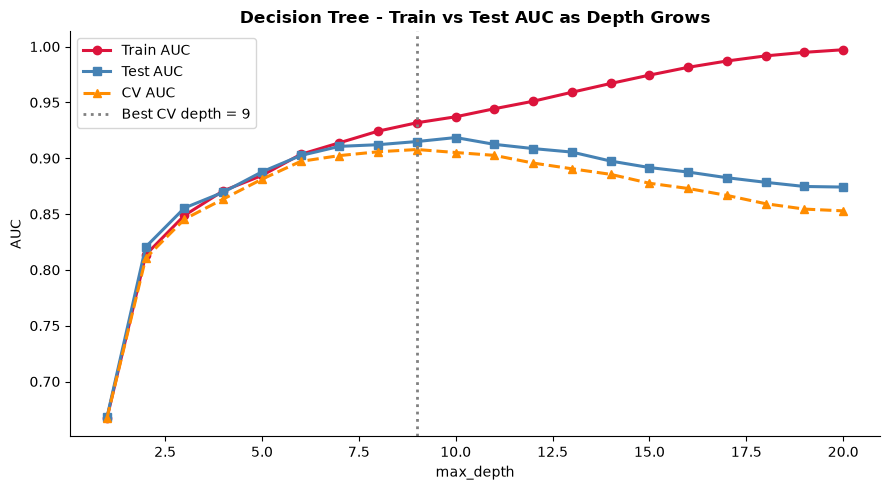

Best depth by CV: 9
Interpretation: Train AUC marches toward 1.0 as the tree memorizes the data, but test
AUC peaks and then DECAYS - the widening gap is textbook overfitting. Capping max_depth
is regularization for trees, the same bias-variance lever as alpha (Wk2) and C (Wk4-5).


In [6]:
# Sweep max_depth and plot TRAIN vs TEST AUC. The gap between them IS overfitting made
# visible - the single most important diagnostic for any tree-based model.
depths = range(1, 21)
rows = []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    t.fit(X_train_enc, y_train)
    rows.append({
        'depth': d,
        'Train AUC': roc_auc_score(y_train, t.predict_proba(X_train_enc)[:, 1]),
        'Test AUC':  roc_auc_score(y_test,  t.predict_proba(X_test_enc)[:, 1]),
        'CV AUC':    cross_val_score(t, X_train_enc, y_train, cv=4, scoring='roc_auc').mean()
    })
depth_df = pd.DataFrame(rows)
best_depth = int(depth_df.loc[depth_df['CV AUC'].idxmax(), 'depth'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depth_df['depth'], depth_df['Train AUC'], marker='o', color='crimson',
        linewidth=2.2, label='Train AUC')
ax.plot(depth_df['depth'], depth_df['Test AUC'], marker='s', color='steelblue',
        linewidth=2.2, label='Test AUC')
ax.plot(depth_df['depth'], depth_df['CV AUC'], marker='^', color='darkorange',
        linewidth=2.2, linestyle='--', label='CV AUC')
ax.axvline(best_depth, color='gray', linestyle=':', linewidth=2,
           label=f'Best CV depth = {best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('AUC')
ax.set_title('Decision Tree - Train vs Test AUC as Depth Grows', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Best depth by CV: {best_depth}")
print("Interpretation: Train AUC marches toward 1.0 as the tree memorizes the data, but test")
print("AUC peaks and then DECAYS - the widening gap is textbook overfitting. Capping max_depth")
print("is regularization for trees, the same bias-variance lever as alpha (Wk2) and C (Wk4-5).")

## 5. Random Forest: Averaging Away the Variance

Random Forest (300 trees)
  OOB score      : 0.9156
  Test AUC       : 0.9345
  vs single tree : 0.8695  ->  gain of +0.0649 AUC

              precision    recall  f1-score   support

      Repaid       0.94      0.96      0.95      5064
     Default       0.84      0.77      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.89      0.87      0.88      6482
weighted avg       0.92      0.92      0.92      6482



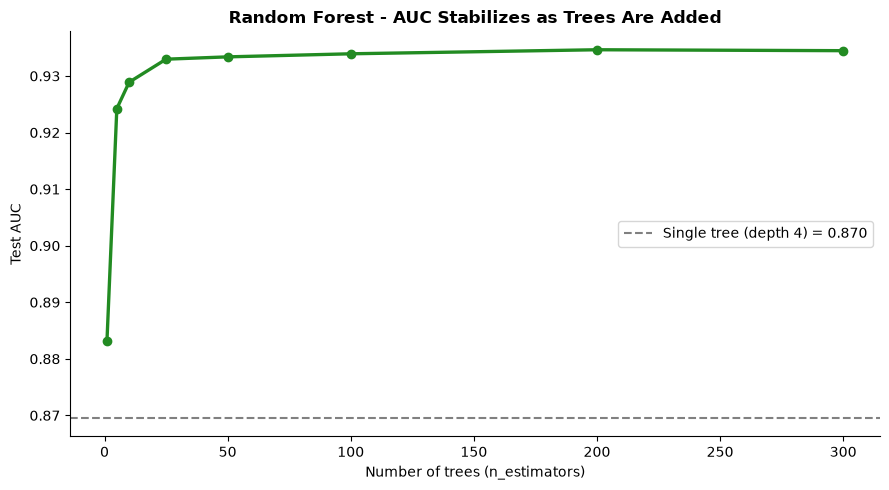

Interpretation: AUC climbs then flattens - past ~100 trees, more trees add compute, not
accuracy. The forest comfortably clears the single tree because averaging de-correlated
trees cancels their individual quirks. OOB tracking test AUC confirms we are not overfit.


In [7]:
# A random forest grows many trees on bootstrap samples, each split seeing a random feature
# subset. Averaging their votes cancels the single tree's variance. OOB score is a built-in
# validation estimate from the ~37% of rows each tree never trained on - free, no holdout cost.
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight='balanced', oob_score=True, n_jobs=-1, random_state=42)
rf.fit(X_train_enc, y_train)
proba_rf = rf.predict_proba(X_test_enc)[:, 1]
auc_rf = roc_auc_score(y_test, proba_rf)

print("Random Forest (300 trees)")
print(f"  OOB score      : {rf.oob_score_:.4f}")
print(f"  Test AUC       : {auc_rf:.4f}")
print(f"  vs single tree : {auc_tree:.4f}  ->  gain of {auc_rf - auc_tree:+.4f} AUC")
print()
print(classification_report(y_test, rf.predict(X_test_enc),
                            target_names=['Repaid', 'Default']))

# n_estimators stability curve
ns = [1, 5, 10, 25, 50, 100, 200, 300]
auc_by_n = []
for n in ns:
    r = RandomForestClassifier(n_estimators=n, min_samples_leaf=5,
                               class_weight='balanced', n_jobs=-1, random_state=42)
    r.fit(X_train_enc, y_train)
    auc_by_n.append(roc_auc_score(y_test, r.predict_proba(X_test_enc)[:, 1]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, auc_by_n, marker='o', color='forestgreen', linewidth=2.4)
ax.axhline(auc_tree, color='gray', linestyle='--', linewidth=1.5,
           label=f'Single tree (depth 4) = {auc_tree:.3f}')
ax.set_xlabel('Number of trees (n_estimators)')
ax.set_ylabel('Test AUC')
ax.set_title('Random Forest - AUC Stabilizes as Trees Are Added', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Interpretation: AUC climbs then flattens - past ~100 trees, more trees add compute, not")
print("accuracy. The forest comfortably clears the single tree because averaging de-correlated")
print("trees cancels their individual quirks. OOB tracking test AUC confirms we are not overfit.")

## 6. Feature Importance: Impurity vs Permutation

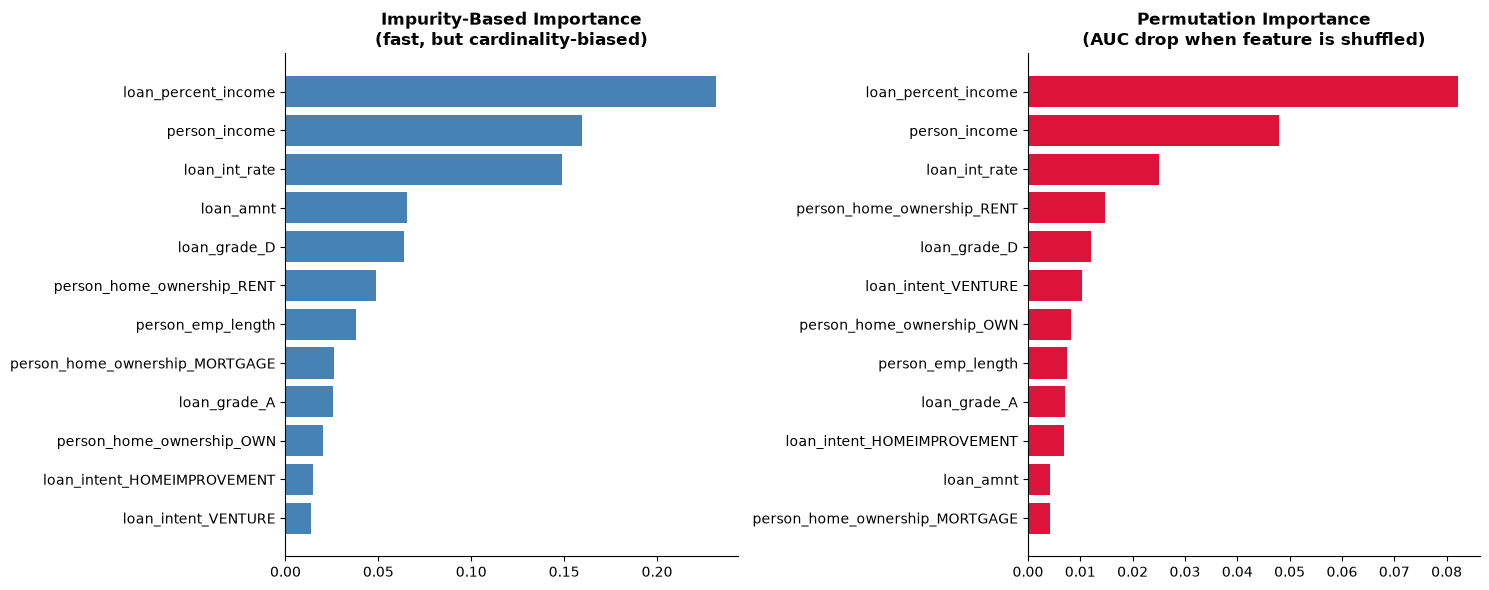

Top default drivers by permutation importance:
                   Feature  Permutation
       loan_percent_income     0.082257
             person_income     0.047891
             loan_int_rate     0.025031
person_home_ownership_RENT     0.014768
              loan_grade_D     0.011980
       loan_intent_VENTURE     0.010339
 person_home_ownership_OWN     0.008142
         person_emp_length     0.007415

What this means for the Chief Risk Officer: the features that survive the permutation
test are the ones the bank should monitor most closely - they carry real, non-redundant
signal about default. Reassuringly, they echo the odds-ratio drivers from Week 4's
logistic model, so two very different model families agree on the underlying risk story.


In [8]:
# Default (impurity) importance is fast but biased toward high-cardinality features.
# Permutation importance is the honest cross-check: shuffle one feature, measure how much
# test AUC drops. A feature that matters will hurt when scrambled.
imp_gini = pd.DataFrame({'Feature': feat_names,
                         'Impurity': rf.feature_importances_})
perm = permutation_importance(rf, X_test_enc, y_test, scoring='roc_auc',
                              n_repeats=8, random_state=42, n_jobs=-1)
imp_perm = pd.DataFrame({'Feature': feat_names,
                         'Permutation': perm.importances_mean})
imp = imp_gini.merge(imp_perm, on='Feature')

top = imp.sort_values('Permutation', ascending=False).head(12)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
g = top.sort_values('Impurity')
axes[0].barh(g['Feature'], g['Impurity'], color='steelblue')
axes[0].set_title('Impurity-Based Importance\n(fast, but cardinality-biased)', fontweight='bold')
p = top.sort_values('Permutation')
axes[1].barh(p['Feature'], p['Permutation'], color='crimson')
axes[1].set_title('Permutation Importance\n(AUC drop when feature is shuffled)', fontweight='bold')
for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Top default drivers by permutation importance:")
print(top.sort_values('Permutation', ascending=False)[['Feature', 'Permutation']]
      .head(8).to_string(index=False))
print()
print("What this means for the Chief Risk Officer: the features that survive the permutation")
print("test are the ones the bank should monitor most closely - they carry real, non-redundant")
print("signal about default. Reassuringly, they echo the odds-ratio drivers from Week 4's")
print("logistic model, so two very different model families agree on the underlying risk story.")

---
## 7. The Capstone Leaderboard: Every Classifier, Head-to-Head

                    Model  Test AUC
      Random Forest (Wk6)    0.9345
      Decision Tree (Wk6)    0.9149
            RBF SVM (Wk5)    0.9025
Logistic Regression (Wk4)    0.8714
         Linear SVM (Wk5)    0.8651


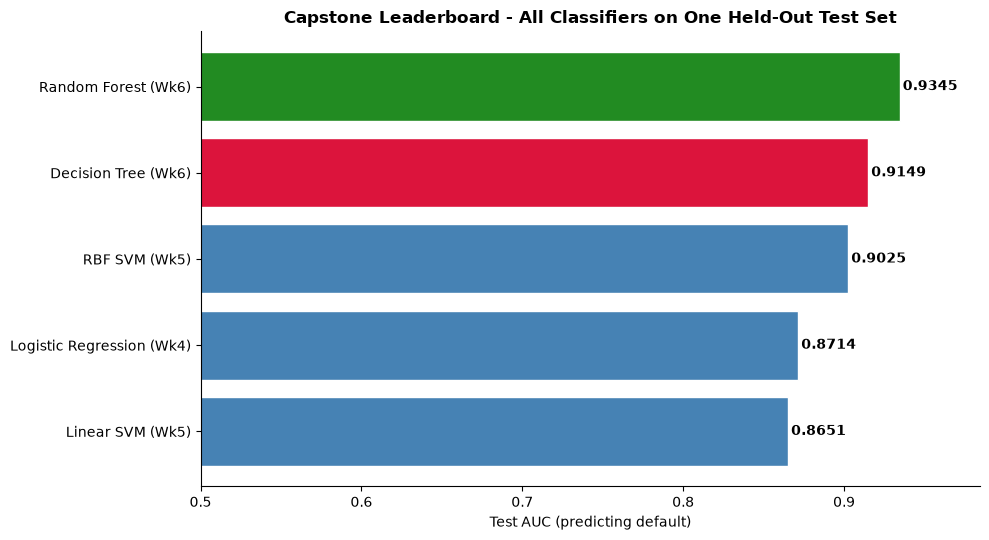


What this means for the Chief Risk Officer: this single chart is the deliverable that
matters. It ranks every approach the project tried on identical, honest footing. Where
the random forest leads, it earns deployment IF the bank can accept reduced
interpretability; where logistic regression is within a whisker, its transparent odds
ratios may be worth the small accuracy cost in a regulated lending decision. The right
model is the one whose accuracy/interpretability trade-off matches the business risk.


In [9]:
# Self-contained re-fit of each model family from Weeks 4-6 on THIS train/test split,
# so the comparison is apples-to-apples. (Logistic & SVM need scaling; trees do not.)
scaled_prep = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# SVM is O(n^2); fit it on a stratified subsample for tractability (as in Week 5).
sub_n = min(6000, len(X_train))
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=sub_n,
                                      random_state=42, stratify=y_train)

contenders = {
    'Logistic Regression (Wk4)': Pipeline([('p', scaled_prep),
        ('m', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
    'Linear SVM (Wk5)': Pipeline([('p', scaled_prep),
        ('m', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42))]),
    'RBF SVM (Wk5)': Pipeline([('p', scaled_prep),
        ('m', SVC(kernel='rbf', gamma='scale', class_weight='balanced',
                  probability=True, random_state=42))]),
    'Decision Tree (Wk6)': Pipeline([('p', encoder),
        ('m', DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced',
                                     random_state=42))]),
    'Random Forest (Wk6)': Pipeline([('p', encoder),
        ('m', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                     class_weight='balanced', n_jobs=-1, random_state=42))]),
}

board = []
for name, model in contenders.items():
    if 'SVM' in name:
        model.fit(X_sub, y_sub)        # subsample for the quadratic-cost models
    else:
        model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    board.append({'Model': name, 'Test AUC': round(roc_auc_score(y_test, proba), 4)})

board_df = pd.DataFrame(board).sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(board_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
order = board_df.sort_values('Test AUC')
colors = ['forestgreen' if 'Forest' in m else 'crimson' if 'Tree' in m
          else 'steelblue' for m in order['Model']]
ax.barh(order['Model'], order['Test AUC'], color=colors, edgecolor='white')
for i, v in enumerate(order['Test AUC']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('Test AUC (predicting default)')
ax.set_title('Capstone Leaderboard - All Classifiers on One Held-Out Test Set',
             fontweight='bold')
ax.set_xlim(0.5, max(board_df['Test AUC']) + 0.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print("What this means for the Chief Risk Officer: this single chart is the deliverable that")
print("matters. It ranks every approach the project tried on identical, honest footing. Where")
print("the random forest leads, it earns deployment IF the bank can accept reduced")
print("interpretability; where logistic regression is within a whisker, its transparent odds")
print("ratios may be worth the small accuracy cost in a regulated lending decision. The right")
print("model is the one whose accuracy/interpretability trade-off matches the business risk.")

### Week 6 Takeaways and Closing the Capstone Loop

**What this week established:**
- A **single decision tree** turns underwriting into readable if/then rules and needs no
  feature scaling, but overfits sharply as depth grows - shown directly by the widening
  train-vs-test AUC gap, with `max_depth` as its regularizer.
- A **random forest** averages hundreds of de-correlated trees to recover stability and
  accuracy; its **OOB score** is a free validation estimate, and AUC flattens once enough
  trees are added.
- **Permutation importance** is the honest importance measure, and it agrees with Week 4's
  logistic odds ratios - two different model families telling the same risk story.
- The **leaderboard** ranks every classifier from Weeks 4-6 on one test set, reframing model
  choice as an explicit accuracy-vs-interpretability trade-off rather than a horse race.